# Avalanches in OGGM

In this series of 2 notebooks, we showcase a recent addition to OGGM: a representation of avalanche contribution to glacier mass balance, based on the work by [Kneib et al. (2025)](https://doi.org/10.1038/s41467-025-65608-z). Here, based on an example for a specific glacier, we first explain how the snow redistribution by avalanches maps were generated for all glaciers in the world.

# Notes on dependencies

We use the small python package which can be run with the latest version of OGGM (v1.6.3):

https://github.com/OGGM/Snowslide

You will need to install this package using pip install.

Dependencies are explained in the README. Note that this package addresses 2 important functionalities:
- snowslide_main.py (which calls functions.py) has all the tools to run the Snowslide avalanche routing on any DEM, competely independently from OGGM
- oggm_snowslide_compat_minimal.py contains a list of functions and objects to link OGGM with Snowslide, starting with snowslide_to_gdir and snowslide_to_gdir_meanmonthly which OGGM calls to produce maps of snow redistribution for its DEMs. 

Snowslide currently runs with pysheds v0.5, which is not part of the default OGGM environment and will need to be installed accordingly in your environment if you wish to produce your own avalanche maps (for example to run this notebook). This can be done easily:

```bash
pip install pysheds=0.5
```

In the most recent OGGM glacier directories we provide maps of snow redistribution by avalanches representative of the calibration period 2000-2019 for all glaciers in the world (level L3, glacier boundaries 80), which can then be ingested in the classic OGGM workflow without the need to re-run Snowslide, therefore with a very limited number of dependencies. 


# Snow redistribution from avalanches maps with OGGM-Snowslide

Let's first load a few basic libraries and initialize the OGGM config and glacier directories as we're used to.

In [1]:
# Libs
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cftime
import time

# Locals
from oggm import cfg, utils, workflow, tasks, DEFAULT_BASE_URL

# Initialize OGGM and set up the default run parameters
cfg.initialize(logging_level='INFO')

# Local working directory (where OGGM will write its output)
dir_path = utils.get_temp_dir('snowslide')
cfg.PATHS['working_dir'] = utils.mkdir(dir_path)

cfg.PARAMS['store_model_geometry'] = True
cfg.PARAMS['min_ice_thick_for_length'] = 1  # a glacier is when ice thicker than 1m

rgi_ids = ['RGI60-11.03638'] # Argentiere Glacier

2026-03-19 16:29:32: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2026-03-19 16:29:32: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2026-03-19 16:29:32: oggm.cfg: Multiprocessing: using all available processors (N=8)
2026-03-19 16:29:32: oggm.cfg: PARAMS['store_model_geometry'] changed from `False` to `True`.
2026-03-19 16:29:32: oggm.cfg: PARAMS['min_ice_thick_for_length'] changed from `0.0` to `1`.


Let's load the glacier directories without avalanche maps

In [2]:
base_url = 'https://cluster.klima.uni-bremen.de/~mkneib/global_snowslide_maps_oggm_2025.6/global_whypso/'
gdirs = workflow.init_glacier_directories(rgi_ids, prepro_base_url=base_url, from_prepro_level=3, prepro_border=80)
gdir = gdirs[0]

2026-03-19 16:29:49: oggm.workflow: init_glacier_directories from prepro level 3 on 1 glaciers.
2026-03-19 16:29:49: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers


Now we're going to run Snowslide for the period 2000-2019 calibration period. This algorithm is based on the work by [Bernhardt & Schulz (2010)](https://doi.org/10.1029/2010GL043086) which basically computes a maximum allowed snow depth for each cell of a DEM based on its slope, and redistributes to lower cells the excess snow. 

This algorithm is computationally expensive and it would be unrealistic to run it on a monthly basis at the global scale. In [Kneib et al. (2025)](https://doi.org/10.1038/s41467-025-65608-z) we explored different options to reduce computation cost while mainatining physical plausability and came to the conclusion that the best compromise was to run Snowslide on a mean monthly basis. This means that for each month we take the average 2000-2019 precipitation and temperature from W5E5 and run Snowslide using these inputs. Snowslide is then only run 12 times for each glacier. More details on the implications can be found in the original paper.

In [3]:
# define start and end years
ys = 2000
ye = 2020
n_years = ye-ys

# Read W5E5 climate data
with xr.open_dataset(gdir.get_filepath('climate_historical')) as ds:
    ds_w5e5 = ds.load()

# monthly temperature and precipitation over the Hugonnet et al. (2021) period (01/2000-01/2020)
temp = ds_w5e5.temp.sel(time=slice("2000-01", "2020-01")).values
prcp = ds_w5e5.prcp.sel(time=slice("2000-01", "2020-01")).values

Once we've aggregated the monthly temperature & precipitation from W5E5 at the reference height of the reanalysis product, these need to be extrapolated to all cells in the glacier's DEM. There are many ways to do this but here we stick to the general OGGM workflow.

In [4]:
# general parameters
default_grad = cfg.PARAMS["temp_default_gradient"]
t_solid = cfg.PARAMS["temp_all_solid"]
t_liq = cfg.PARAMS["temp_all_liq"]
t_melt = cfg.PARAMS["temp_melt"]

grad = prcp * 0 + default_grad # temperature lapse rate with the same dimensions than the temperature and precipitation time-series
ref_hgt = ds_w5e5.ref_hgt # reference height of W5E5 cell

# Load the glacier DEM (to compute the initial distributed snow height)
gridded_data_path = gdir.get_filepath("gridded_data")
with xr.open_dataset(gridded_data_path) as ds:
    ds = ds.load()

In addition to the parameters to calculate the distributed snow depth we also need to define the SnowSlide parameters related to the routing of the snow to lower cells. There are several options in Snowslide but based on extensive tests, we recommend using a Multiple Direction Flow routing and to allow propagation. The latter corresponds to reducing by 30% the maximum snow depth after the first iteration to account for the inertia of the avalanche, following the recommendations of [Quéno et al. (2024)](https://doi.org/10.5194/tc-18-3533-2024). This choice of parameters results in more realistic snow redistribution patterns.

In [5]:
# snowslide parameters
routing="mfd"
Propagation=True
param_routing = {"routing": routing, "preprocessing": True, "compute_edges": True}

Now it's time to run snowslide MEAN MONTHLY over the full time period. These nested for loops will allow to compute the snow depth before and after redistribution for all 12 months of the year, which are then summed to get the total annual snow depth with and without avalanches.

Note that to compute the snow depth we use a density conversion factor of 200 kg/m3 for snow which has quite a strong effect on the snow redistribution patterns. This could be adapted for glacier locations / periods of the year, but would need to be justified with a calibration of some sort. In [Kneib et al. (2025)](https://doi.org/10.1038/s41467-025-65608-z), we stuck to this fixed value, but more focus work on this would be welcome :)

In [6]:
# import Snowslide
from snowslide.snowslide_main import snowslide_base

# get path to DEM for SnowSlide
path_to_dem = gdir.get_filepath("dem") 

# Initialize snow depths maps - maps of the same size as the DEM, full of zeros
snd_before = xr.zeros_like(ds['topo'])
snd_after = xr.zeros_like(ds['topo'])

# Snow density
rho_freshsnow = 200 # in kg/m3

# loop through all 12 months of the year
for ii in range(0, 12):

    # Get the mean 2000-2019 distributed snow depth
    sndm = np.zeros_like(ds.topo.data)
    for jj in range(0,n_years):
        # temperature, precipitation and temperature lapse rate at given month & year
        itemp = temp[ii+jj*12]
        iprcp = prcp[ii+jj*12]
        igrad = grad[ii+jj*12]

        # compute elevation of liquid and solid precip
        zliq = ref_hgt + (t_liq-itemp)/igrad
        zsolid = ref_hgt + (t_solid-itemp)/igrad

        # Compute initial snow depth
        snd0 = np.ones_like(ds.topo.data)
        snd0[ds.topo.data>zsolid] = iprcp
        snd0[ds.topo.data<zliq] = 0
        heights_mix = ds.topo.data[(ds.topo.data<=zsolid) & (ds.topo.data>=zliq)]
        snd0[(ds.topo.data<=zsolid) & (ds.topo.data>=zliq)] = iprcp * 1 - (itemp + igrad * (heights_mix - ref_hgt) - t_solid) / (t_liq - t_solid)

        # Convert to snow height (density conversion from kg/m2)
        snd0 = snd0/rho_freshsnow
        
        # add to monthly snow depth
        sndm = sndm+snd0

    sndm = sndm/n_years

    # Run snowslide
    snd = snowslide_base(
        path_to_dem,
        snd0=sndm,
        param_routing=param_routing,
        glacier_id=f"({gdir.rgi_id}) ",
        propagation_boolean=Propagation
    )

    # allocate 
    snd_after = snd_after+snd
    snd_before = snd_before+sndm

    # Print progress
    print(f'Progress: {ii + 1}/{12} completed', end='\r')

2026-03-19 16:34:37: snowslide.snowslide_main: (RGI60-11.03638) the algorithm converged in 36 iterations


2026-03-19 16:34:45: snowslide.snowslide_main: (RGI60-11.03638) the algorithm converged in 23 iterations


2026-03-19 16:34:58: snowslide.snowslide_main: (RGI60-11.03638) the algorithm converged in 31 iterations


2026-03-19 16:35:06: snowslide.snowslide_main: (RGI60-11.03638) the algorithm converged in 22 iterations


2026-03-19 16:35:19: snowslide.snowslide_main: (RGI60-11.03638) the algorithm converged in 33 iterations


...

2026-03-19 16:35:41: snowslide.snowslide_main: (RGI60-11.03638) the algorithm converged in 17 iterations


2026-03-19 16:35:49: snowslide.snowslide_main: (RGI60-11.03638) the algorithm converged in 21 iterations


2026-03-19 16:35:59: snowslide.snowslide_main: (RGI60-11.03638) the algorithm converged in 24 iterations


2026-03-19 16:36:11: snowslide.snowslide_main: (RGI60-11.03638) the algorithm converged in 31 iterations


2026-03-19 16:36:25: snowslide.snowslide_main: (RGI60-11.03638) the algorithm converged in 33 iterations


As you can see, even just running Snowslide 12 times for one glacier takes a few tens of seconds, up to 2-3 minutes for a large glacier. Also note that the number of iterations scales with snow depth - in the case of Argentière Glacier, most of the solid precipitation falls in the winter months, so more snow needs to be redistributed during that period.

Let's now have a look at these snow depth maps!

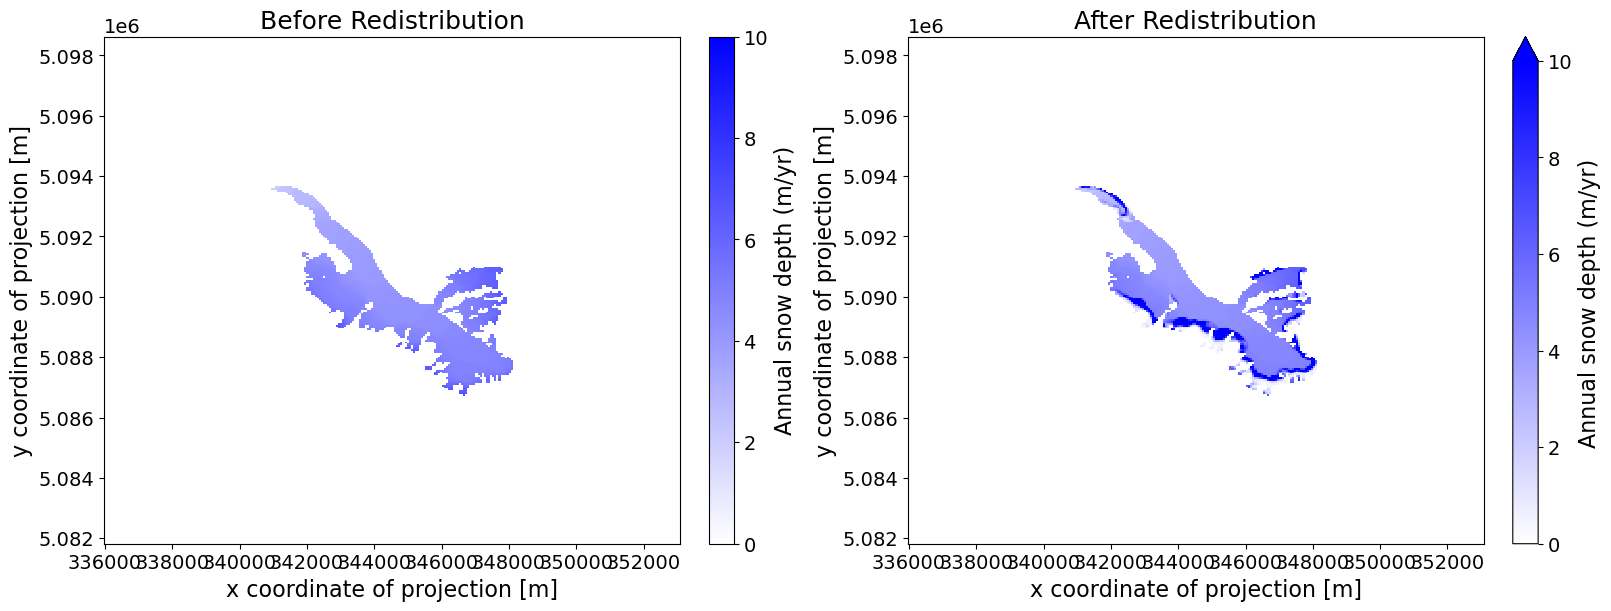

In [7]:
# Define a colormap from white to blue
from matplotlib.colors import LinearSegmentedColormap
white_to_blue = LinearSegmentedColormap.from_list("WhiteToBlue", ["white", "blue"])

# Fonts
plt.rcParams.update({'font.size': 14, 'axes.titlesize': 18, 'axes.labelsize': 16})

# Plotting figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

datasets = [snd_before, snd_after]
titles = ["Before Redistribution", "After Redistribution"]

for ax, data, title in zip(axes, datasets, titles):
    img = data.where(ds.glacier_mask).plot.imshow(
        ax=ax, 
        cmap=white_to_blue, 
        vmin=0, 
        vmax=10, 
        add_colorbar=True,
        cbar_kwargs={'label': 'Annual snow depth (m/yr)'}
    )
    ax.set_title(title)

plt.show()

You can adapt the extents of the colorscale depending on the glacier you're interested in. For Argentière, without redistribution the annual snowfall gradually increases up-glacier. Indeed, while all the cells receive the same amount of precipitation, there's a higher portion of it falling as rain at lower elevations. The patterns after resdistribution highlight much stronger spatial variability, with the steeper parts of the glacier not retaining any snow while there are some very strong local accumulations.

This can be visualized better by plotting the difference of the 2 maps.

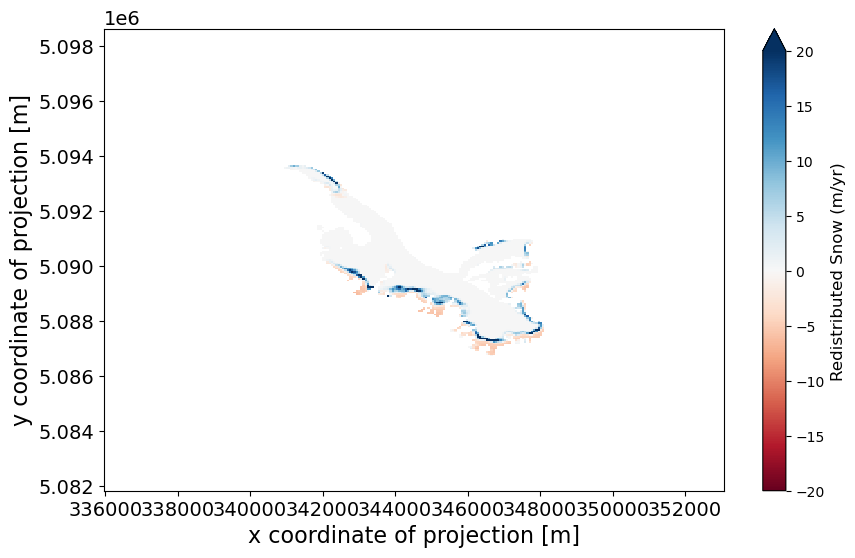

In [8]:
redistributed_snow = snd_after-snd_before

fig, ax = plt.subplots(figsize=(10, 6))
img = redistributed_snow.where(ds.glacier_mask).plot.imshow(cmap="RdBu", vmin=-20, vmax=20, add_colorbar=True)
img.colorbar.set_label("Redistributed Snow (m/yr)", fontsize=12)
img.colorbar.ax.tick_params(labelsize=10)
plt.show()

Note that for visualization we clipped the snow maps to the glacier outlines, but these snow redistribution patterns are available for the entire DEM, so the workflow below would still work if you wanted to change the glacier outlines (taking RGI 7 for example) 

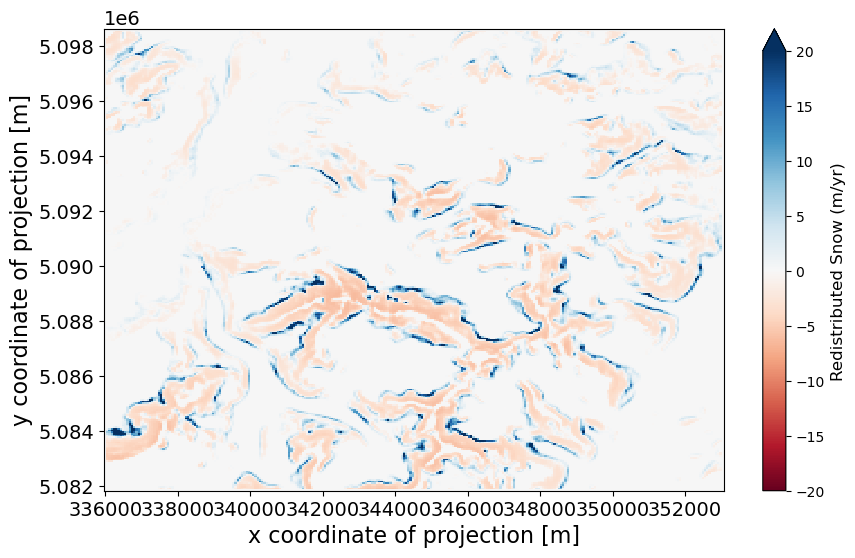

In [9]:
# plot the same snow redistribution map, without clipping to the glacier outlines
fig, ax = plt.subplots(figsize=(10, 6))
img = redistributed_snow.plot.imshow(cmap="RdBu", vmin=-20, vmax=20, add_colorbar=True)
img.colorbar.set_label("Redistributed Snow (m/yr)", fontsize=12)
img.colorbar.ax.tick_params(labelsize=10)
plt.show()

Instead of taking the difference of the snow depth maps, one can take the ratio, which we refer to as the 'avalanche correction factor' of precipitation

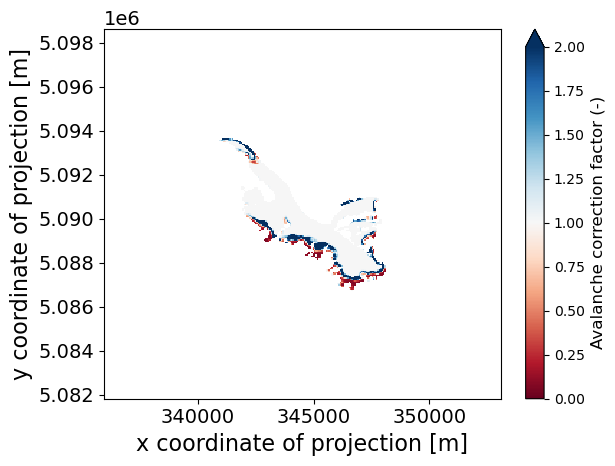

In [10]:
# pfact from snd_after & snd_before
pfact = snd_after/snd_before

img = pfact.where(ds.glacier_mask).plot.imshow(cmap="RdBu", vmin=0, vmax=2, add_colorbar=True)
img.colorbar.set_label("Avalanche correction factor (-)", fontsize=12)
img.colorbar.ax.tick_params(labelsize=10)
plt.show()

This avalanche correction factor can then be saved as a gridded product of the glacier directories.

In [11]:
# Write to get gridded snowline_1m product
with utils.ncDataset(gdir.get_filepath("gridded_data"), "a") as nc:
    vn = "snowslide_1m"

    # delete the variable if it already exists
    if vn in nc.variables:
        v = nc.variables[vn]
    else:
        # create the variable
        v = nc.createVariable(vn, "f4", ("y", "x"), zlib=True)

        # set attributes
        v.units = "m"
        v.long_name = "Snowcover after avalanches"
        # assign data to variable
        v[:] = pfact

Introducing avalanches therefore introduces a strong spatial variability in the accumulation patterns! Question now is how to take this into account in our glacier mass balance model!?

Check out the follow-up notebook which focuses on using these distributed avalanche correction factors in your mass balance model.